# Memo Graphs

4 rows × 5 columns — one row per population bin, one column per graph-structural metric, all over time (1980–2020).

| Row | Population bin |
|-----|---------------|
| 0   | 50k – 100k    |
| 1   | 100k – 500k   |
| 2   | 500k – 1M     |
| 3   | 1M+           |

Columns: **num_leaves · max_degree · num_edges · num_nodes · graph_density**

Graph density = 2E / (N(N−1)) for an undirected simple graph.

In [90]:
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import pandas as pd

YEARS                 = [1980,1990, 2000, 2010, 2020]
CBSA_DIR              = '../study_areas'
CENSUS_GEOGRAPHY_TYPE = 'block_groups'
SAMPLE_SIZE           = None   # None = load all files
VINTAGE               = 'march_2020'

In [91]:
_cbsa_df  = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [92]:
import re as _re


def _count_triangles(adj_raw, nodes_list):
    """
    Count triangles via set-intersection on the raw JSON adjacency.
    adj_raw[i] is a list of dicts with an 'id' key.
    For each edge (i, j) with i < j, count |N(i) ∩ N(j)|.
    Each triangle is counted once per edge (3 times total), so divide by 3.
    """
    id_to_idx = {node['id']: i for i, node in enumerate(nodes_list)}
    adj_sets = [
        frozenset(id_to_idx[nb['id']] for nb in neighbors if nb['id'] in id_to_idx)
        for neighbors in adj_raw
    ]
    count = 0
    for i, nbrs in enumerate(adj_sets):
        for j in nbrs:
            if j > i:
                count += len(nbrs & adj_sets[j])
    return count // 3


def load_year(year, vintage=None, sample_size=None, cbsa_names=None):
    pattern = os.path.join(
        CBSA_DIR, str(year),
        f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_*_{year}_*_vintage_connected.json'
    )
    files = sorted(glob.glob(pattern))
    if vintage is not None:
        files = [f for f in files if vintage in os.path.basename(f)]
    if sample_size is not None:
        files = files[:sample_size]

    records = []
    for fp in files:
        try:
            with open(fp) as f:
                d = json.load(f)
            nodes   = d['nodes']
            adj     = d['adjacency']
            n_nodes = len(nodes)
            n_edges = sum(len(a) for a in adj) // 2
            degrees = [len(a) for a in adj]
            n_leaves = sum(1 for deg in degrees if deg == 1)
            max_deg  = max(degrees) if degrees else 0
            density  = (n_edges / (3 * n_nodes - 6)
                        if n_nodes >= 3 else 0.0)
            n_triangles      = _count_triangles(adj, nodes)
            n_possible       = n_nodes * (n_nodes - 1) * (n_nodes - 2) // 6
            triangle_density = n_triangles / n_possible if n_possible > 0 else 0.0
            n_triples        = sum(d * (d - 1) // 2 for d in degrees)
            transitivity     = 3 * n_triangles / n_triples if n_triples > 0 else 0.0
            sum_totpop = sum((n.get('TOTPOP') or 0) for n in nodes)
            sum_poc    = sum((n.get('POC')    or 0) for n in nodes)
            sum_black  = sum((n.get('BLACK')  or 0) for n in nodes)
            sum_white  = sum((n.get('WHITE')  or 0) for n in nodes)
            poc_share   = sum_poc   / sum_totpop               if sum_totpop > 0               else np.nan
            black_share = sum_black / (sum_black + sum_white)  if (sum_black + sum_white) > 0  else np.nan
            fname = os.path.basename(fp)
            m = _re.search(r'_in_cbsa_(\d+)_', fname)
            code  = int(m.group(1)) if m else None
            name  = cbsa_names.get(code, '') if cbsa_names and code is not None else ''
            records.append({
                'file':             fname,
                'cbsa_code':        code,
                'cbsa_name':        name,
                'n_nodes':          n_nodes,
                'n_edges':          n_edges,
                'n_leaves':         n_leaves,
                'max_deg':          max_deg,
                'density':          density,
                'n_triangles':      n_triangles,
                'triangle_density': triangle_density,
                'transitivity':     transitivity,
                'total_pop':        sum_totpop,
                'poc_share':        poc_share,
                'black_share':      black_share,
            })
        except Exception as e:
            print(f'  skipped {os.path.basename(fp)}: {e}')
    return records


data = {}
for yr in [1980, 1990, 2000, 2010, 2020]:
    print(f'Loading {yr}...', end=' ', flush=True)
    records = load_year(yr, vintage=VINTAGE, sample_size=SAMPLE_SIZE, cbsa_names=cbsa_dict)
    if records:
        data[yr] = records
        print(f'{len(records)} graphs')
    else:
        print('no files found, skipping')

YEARS = sorted(data.keys())
print(f'Active years: {YEARS}')

Loading 1980... no files found, skipping
Loading 1990... 384 graphs
Loading 2000... 392 graphs
Loading 2010... 392 graphs
Loading 2020... 392 graphs
Active years: [1990, 2000, 2010, 2020]


/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_33588/3344694298.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.015, 1, 0.987], pad=0.1)


Saved figures/memo_graphs_edges_nodes.png


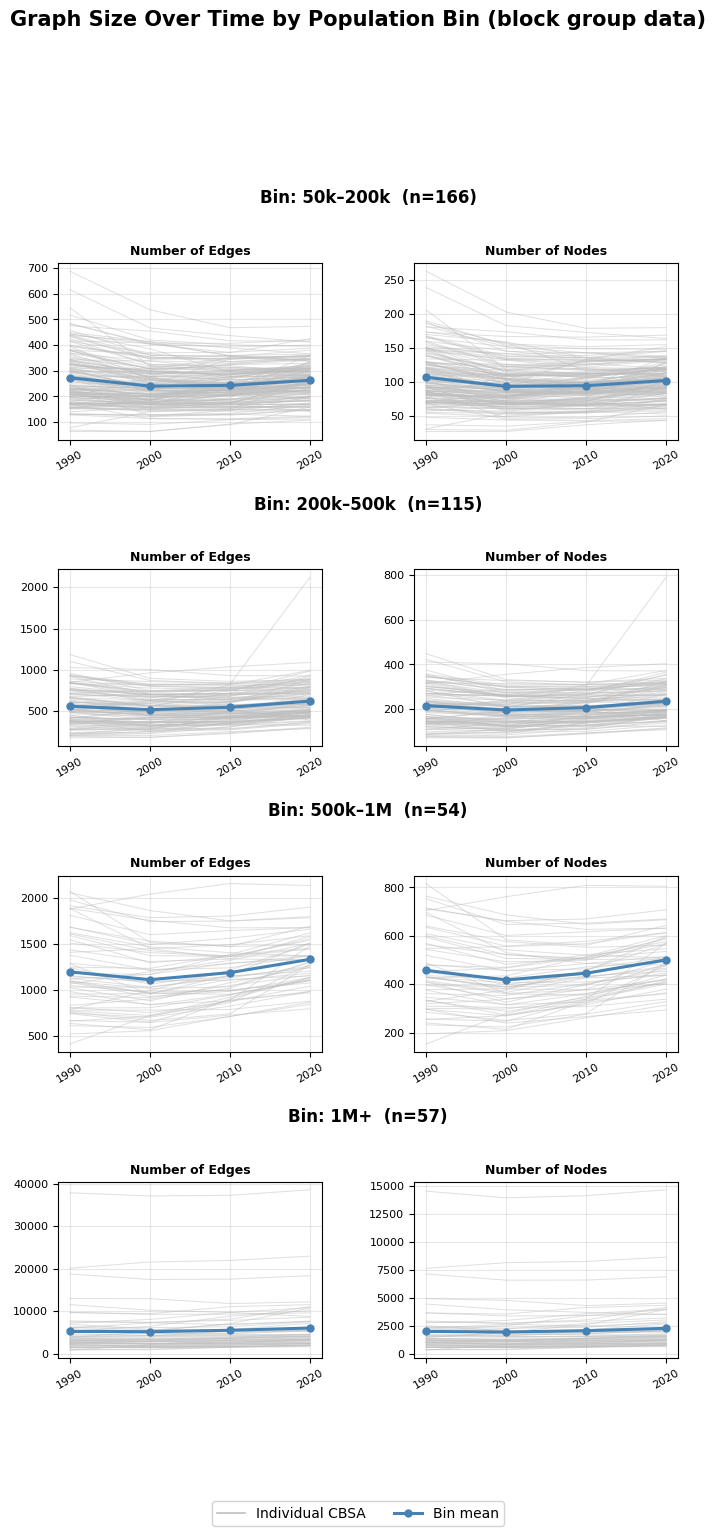

Saved figures/memo_graphs_density.png


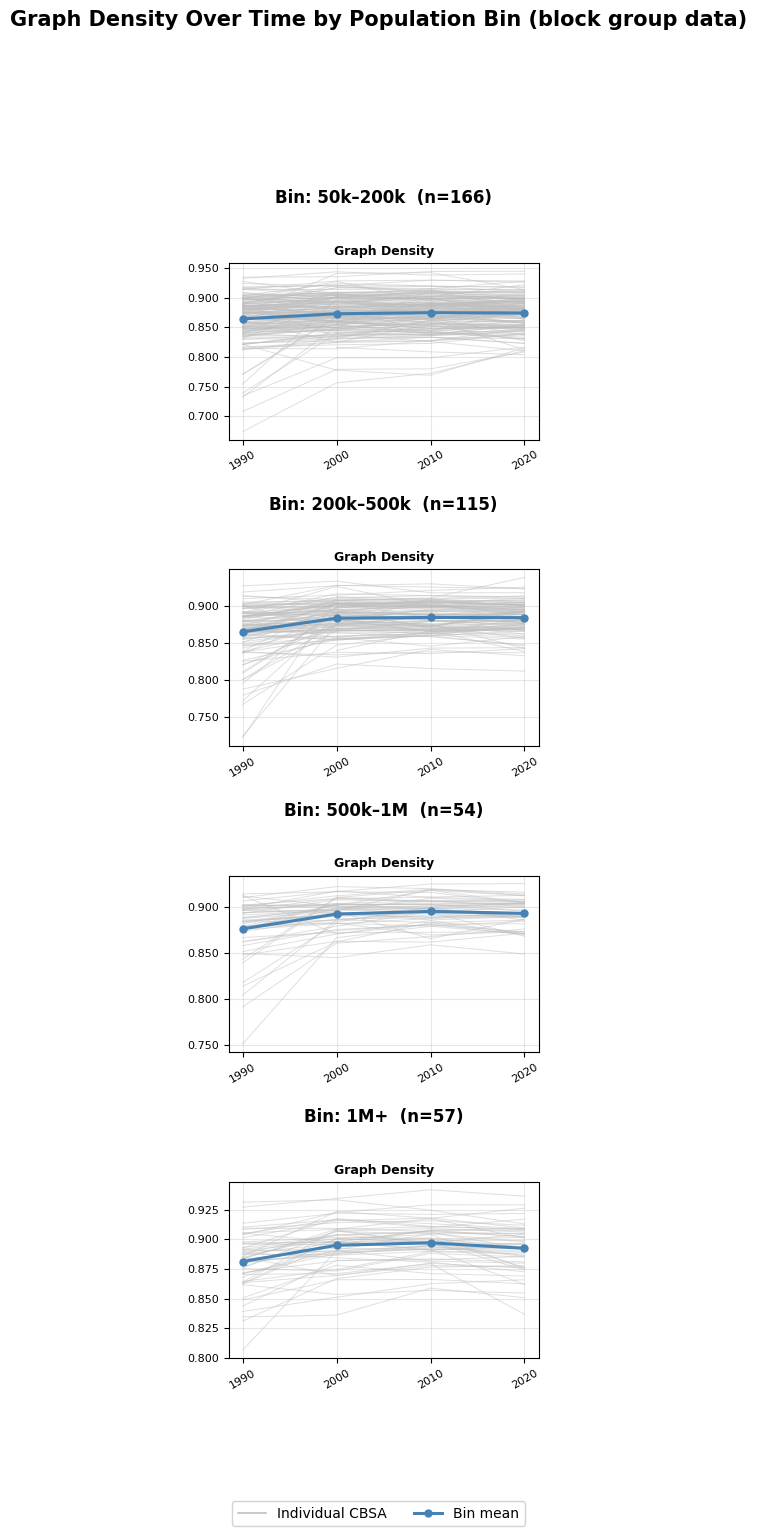

Saved figures/memo_graphs_degree_leaves.png


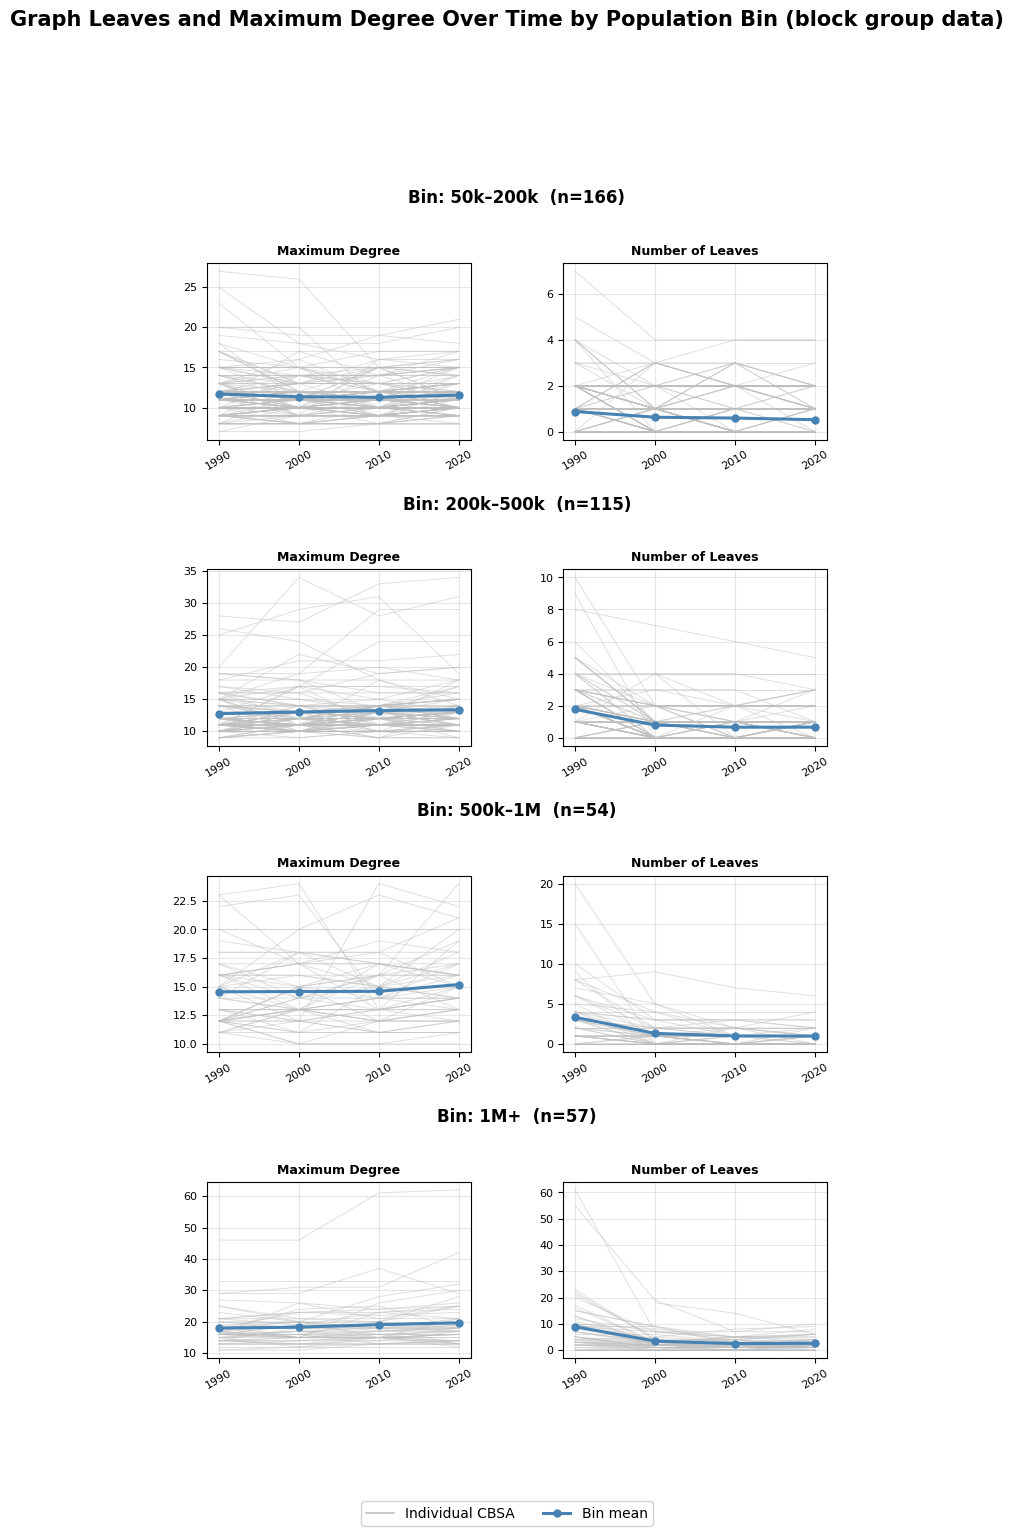

In [93]:
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

BINS = [
    ('50k–200k',    50_000,    200_000),
    ('200k–500k',  200_000,    500_000),
    ('500k–1M',    500_000,  1_000_000),
    ('1M+',      1_000_000, float('inf')),
]

all_years = sorted(data.keys())

cbsa_data = {}
for yr in all_years:
    for r in data[yr]:
        code = r.get('cbsa_code')
        if code is not None:
            cbsa_data.setdefault(code, {})[yr] = r

pop_2020 = {
    r['cbsa_code']: r['total_pop']
    for r in data.get(2020, [])
    if r.get('cbsa_code') is not None
}

bin_codes = [
    [c for c, p in pop_2020.items() if lo <= p < hi]
    for (_, lo, hi) in BINS
]

geo_label = 'tract data' if CENSUS_GEOGRAPHY_TYPE == 'tracts' else 'block group data'


def binned_plot(metrics, filename, title):
    metrics = [(m[0], m[1], m[2] if len(m) > 2 else None) for m in metrics]
    n_rows = len(BINS)
    n_cols = len(metrics)
    height_ratios = [h for _ in BINS for h in (0.12, 1.0)]

    fig = plt.figure(figsize=(4 * n_cols, 3.8 * n_rows))
    fig.suptitle(f'{title} by Population Bin ({geo_label})',
                 fontsize=15, fontweight='bold', y=0.997)
    gs = GridSpec(2 * n_rows, n_cols, figure=fig,
                  height_ratios=height_ratios, hspace=0.55, wspace=0.35)

    for row, ((bin_label, _, __), codes) in enumerate(zip(BINS, bin_codes)):
        hax = fig.add_subplot(gs[row * 2, :])
        hax.set_axis_off()
        hax.text(0.5, 0.5, f'Bin: {bin_label}  (n={len(codes)})',
                 transform=hax.transAxes, ha='center', va='center',
                 fontsize=12, fontweight='bold')

    axes_grid = [
        [fig.add_subplot(gs[row * 2 + 1, col]) for col in range(n_cols)]
        for row in range(n_rows)
    ]

    for row, (bin_label, lo, hi) in enumerate(BINS):
        codes = bin_codes[row]
        for col, (metric_key, metric_label, fmt) in enumerate(metrics):
            ax = axes_grid[row][col]

            for code in codes:
                city = cbsa_data.get(code, {})
                pts = [
                    (yr, city[yr][metric_key])
                    for yr in all_years
                    if yr in city
                    and city[yr].get(metric_key) is not None
                    and not (isinstance(city[yr][metric_key], float)
                             and np.isnan(city[yr][metric_key]))
                ]
                if len(pts) >= 2:
                    yrs_i, vals_i = zip(*pts)
                    ax.plot(yrs_i, vals_i, color='#c0c0c0', linewidth=0.7,
                            alpha=0.5, zorder=1)

            mean_yrs, mean_vals = [], []
            for yr in all_years:
                yr_vals = [
                    cbsa_data[c][yr][metric_key]
                    for c in codes
                    if yr in cbsa_data.get(c, {})
                    and cbsa_data[c][yr].get(metric_key) is not None
                    and not (isinstance(cbsa_data[c][yr].get(metric_key), float)
                             and np.isnan(cbsa_data[c][yr].get(metric_key)))
                ]
                if yr_vals:
                    mean_yrs.append(yr)
                    mean_vals.append(float(np.mean(yr_vals)))

            if mean_yrs:
                ax.plot(mean_yrs, mean_vals, color='steelblue', linewidth=2.2,
                        marker='o', markersize=5, zorder=2)

            ax.set_title(metric_label, fontsize=9, fontweight='bold')
            if fmt:
                ax.yaxis.set_major_formatter(fmt)
            ax.set_xticks(all_years)
            ax.tick_params(labelsize=8, axis='x', rotation=30)
            ax.tick_params(labelsize=8, axis='y')
            ax.grid(True, alpha=0.3)

    legend_handles = [
        Line2D([0], [0], color='#c0c0c0', linewidth=1.2, label='Individual CBSA'),
        Line2D([0], [0], color='steelblue', linewidth=2.2,
               marker='o', markersize=5, label='Bin mean'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.005), framealpha=0.85)

    plt.tight_layout(rect=[0, 0.015, 1, 0.987], pad=0.1)
    os.makedirs('figures', exist_ok=True)
    fig.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    print(f'Saved figures/{filename}')
    plt.show()


binned_plot(
    [('n_edges', 'Number of Edges'), ('n_nodes', 'Number of Nodes')],
    'memo_graphs_edges_nodes.png',
    'Graph Size Over Time',
)

binned_plot(
    [('density', 'Graph Density',
      mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))],
    'memo_graphs_density.png',
    'Graph Density Over Time',
)

binned_plot(
    [('max_deg', 'Maximum Degree'), ('n_leaves', 'Number of Leaves')],
    'memo_graphs_degree_leaves.png',
    'Graph Leaves and Maximum Degree Over Time',
)

Saved figures/memo_graphs_top10.png


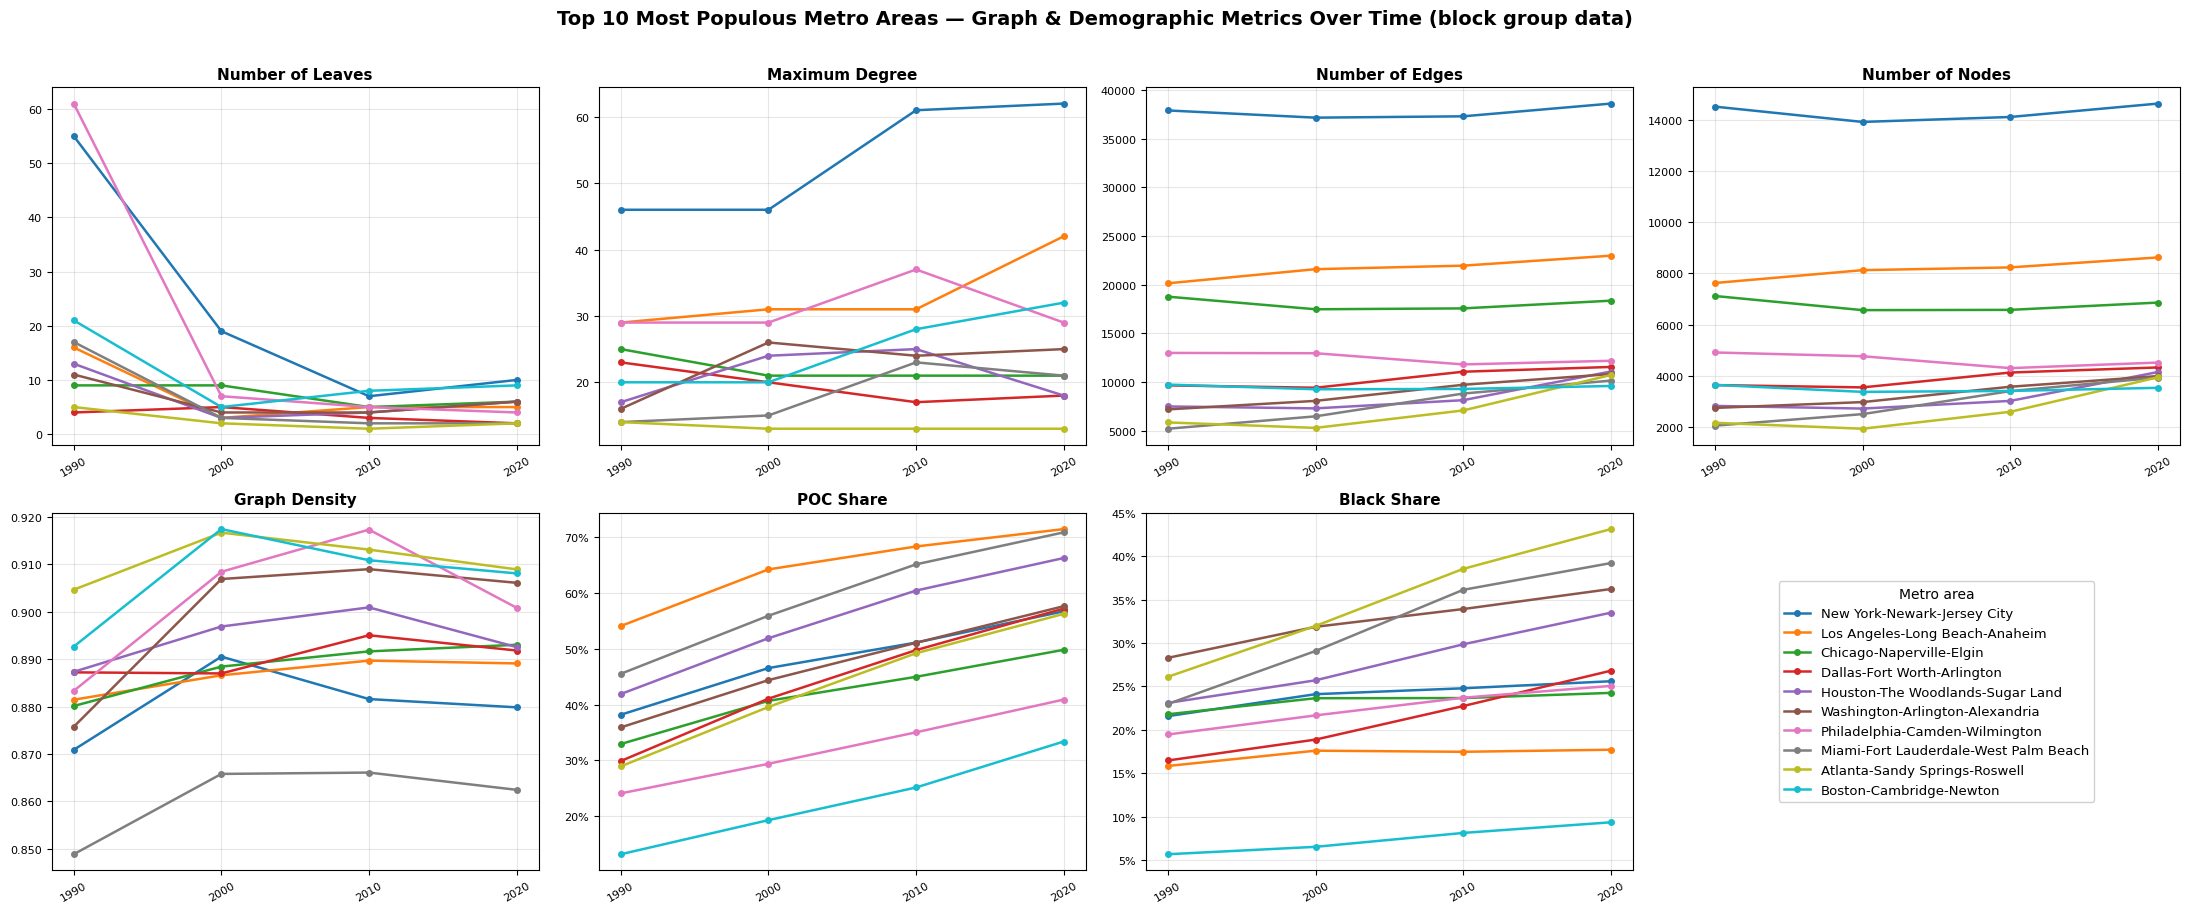

In [94]:
# ── Top-10 most populous metros — spaghetti plots ─────────────────────────────

METRICS_TOP10 = [
    ('n_leaves',    'Number of Leaves', None),
    ('max_deg',     'Maximum Degree',   None),
    ('n_edges',     'Number of Edges',  None),
    ('n_nodes',     'Number of Nodes',  None),
    ('density',     'Graph Density',
     mticker.FuncFormatter(lambda x, _: f'{x:.3f}')),
    ('poc_share',   'POC Share',
     mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
    ('black_share', 'Black Share',
     mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
]

top10_codes = sorted(pop_2020, key=lambda c: pop_2020[c], reverse=True)[:10]
# Shorten names: keep the city part before the state suffix
top10_names = [cbsa_dict.get(c, str(c)).split(',')[0] for c in top10_codes]

colors = [cm.tab10(i / 10) for i in range(10)]

n_metrics = len(METRICS_TOP10)   # 7
n_cols_sp = 4
n_rows_sp = 2   # 7 panels + 1 legend panel = 8 = 2×4

geo_label = 'tract data' if CENSUS_GEOGRAPHY_TYPE == 'tracts' else 'block group data'

fig, axes = plt.subplots(n_rows_sp, n_cols_sp,
                         figsize=(5.5 * n_cols_sp, 4.5 * n_rows_sp))
fig.suptitle(f'Top 10 Most Populous Metro Areas — Graph & Demographic Metrics Over Time ({geo_label})',
             fontsize=14, fontweight='bold', y=1.01)

for idx, (metric_key, metric_label, fmt) in enumerate(METRICS_TOP10):
    ax = axes[idx // n_cols_sp][idx % n_cols_sp]

    for i, (code, name) in enumerate(zip(top10_codes, top10_names)):
        city = cbsa_data.get(code, {})
        pts = [
            (yr, city[yr][metric_key])
            for yr in all_years
            if yr in city
            and city[yr].get(metric_key) is not None
            and not (isinstance(city[yr][metric_key], float)
                     and np.isnan(city[yr][metric_key]))
        ]
        if len(pts) >= 2:
            yrs_i, vals_i = zip(*pts)
            ax.plot(yrs_i, vals_i, color=colors[i], linewidth=1.8,
                    marker='o', markersize=4, label=name)

    ax.set_title(metric_label, fontsize=11, fontweight='bold')
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
    ax.set_xticks(all_years)
    ax.tick_params(labelsize=8, axis='x', rotation=30)
    ax.tick_params(labelsize=8, axis='y')
    ax.grid(True, alpha=0.3)

# Last panel (index 7) becomes the legend
legend_ax = axes[1][3]
legend_ax.set_axis_off()
handles, labels = axes[0][0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', fontsize=9.5,
                 framealpha=0.9, title='Metro area', title_fontsize=10)

plt.tight_layout()
fig.savefig('figures/memo_graphs_top10.png', dpi=150, bbox_inches='tight')
print('Saved figures/memo_graphs_top10.png')
plt.show()

Saved figures/memo_unbinned_leaves_degree.png


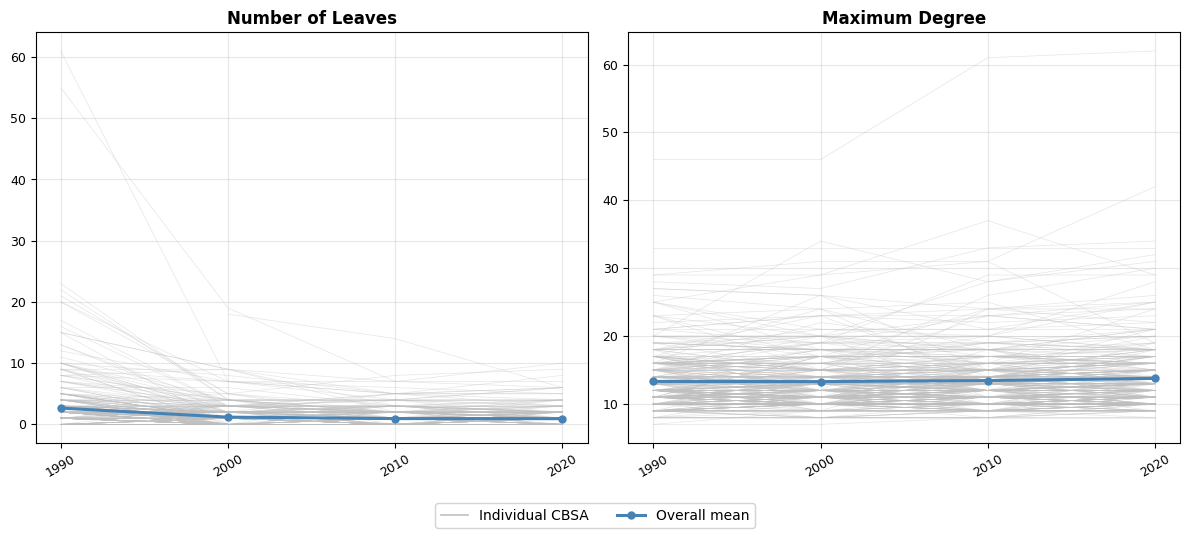

Saved figures/memo_unbinned_edges_nodes.png


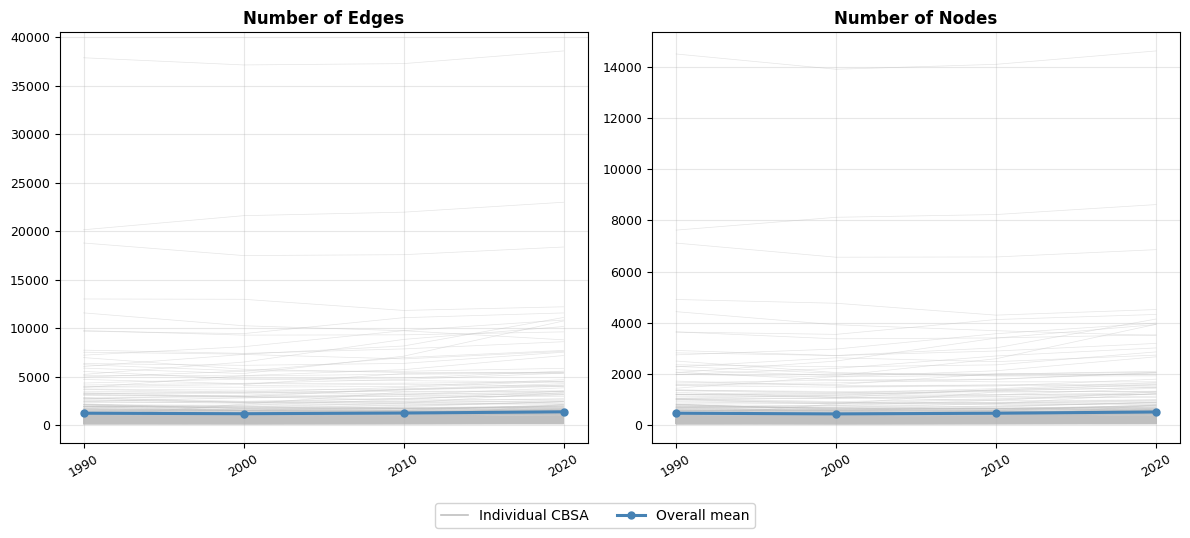

Saved figures/memo_unbinned_density.png


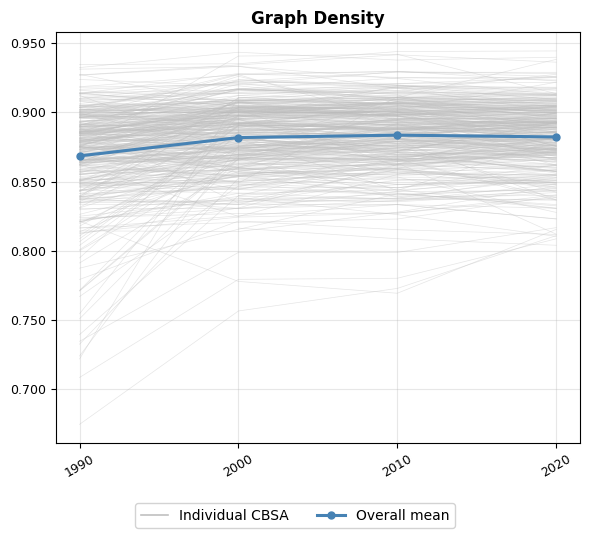

In [95]:
# ── Unbinned spaghetti plots ───────────────────────────────────────────────────
# Three figures; each panel: grey lines for every CBSA, blue line = overall mean.

all_codes = list(cbsa_data.keys())
geo_label = 'tract data' if CENSUS_GEOGRAPHY_TYPE == 'tracts' else 'block group data'

def unbinned_spaghetti(fig_metrics, filename):
    n_panels = len(fig_metrics)
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5),
                             squeeze=False)
    axes = axes[0]

    for ax, (metric_key, metric_label, fmt) in zip(axes, fig_metrics):
        for code in all_codes:
            city = cbsa_data.get(code, {})
            pts = [
                (yr, city[yr][metric_key])
                for yr in all_years
                if yr in city
                and city[yr].get(metric_key) is not None
                and not (isinstance(city[yr][metric_key], float)
                         and np.isnan(city[yr][metric_key]))
            ]
            if len(pts) >= 2:
                yrs_i, vals_i = zip(*pts)
                ax.plot(yrs_i, vals_i, color='#c0c0c0', linewidth=0.5,
                        alpha=0.4, zorder=1)

        # Overall mean across all CBSAs
        mean_yrs, mean_vals = [], []
        for yr in all_years:
            yr_vals = [
                cbsa_data[c][yr][metric_key]
                for c in all_codes
                if yr in cbsa_data.get(c, {})
                and cbsa_data[c][yr].get(metric_key) is not None
                and not (isinstance(cbsa_data[c][yr].get(metric_key), float)
                         and np.isnan(cbsa_data[c][yr].get(metric_key)))
            ]
            if yr_vals:
                mean_yrs.append(yr)
                mean_vals.append(float(np.mean(yr_vals)))

        if mean_yrs:
            ax.plot(mean_yrs, mean_vals, color='steelblue', linewidth=2.2,
                    marker='o', markersize=5, zorder=2, label='Overall mean')

        ax.set_title(metric_label, fontsize=12, fontweight='bold')
        if fmt:
            ax.yaxis.set_major_formatter(fmt)
        ax.set_xticks(all_years)
        ax.tick_params(labelsize=9, axis='x', rotation=30)
        ax.tick_params(labelsize=9, axis='y')
        ax.grid(True, alpha=0.3)

    legend_handles = [
        Line2D([0], [0], color='#c0c0c0', linewidth=1.2, label='Individual CBSA'),
        Line2D([0], [0], color='steelblue', linewidth=2.2,
               marker='o', markersize=5, label='Overall mean'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.08), framealpha=0.85)
    plt.tight_layout()
    fig.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    print(f'Saved figures/{filename}')
    plt.show()


unbinned_spaghetti(
    [
        ('n_leaves', 'Number of Leaves',  None),
        ('max_deg',  'Maximum Degree',    None),
    ],
    f'memo_unbinned_leaves_degree.png',
)

unbinned_spaghetti(
    [
        ('n_edges', 'Number of Edges', None),
        ('n_nodes', 'Number of Nodes', None),
    ],
    f'memo_unbinned_edges_nodes.png',
)

unbinned_spaghetti(
    [
        ('density', 'Graph Density',
         mticker.FuncFormatter(lambda x, _: f'{x:.3f}')),
    ],
    f'memo_unbinned_density.png',
)

Saved figures/memo_scatter_size_pop.png


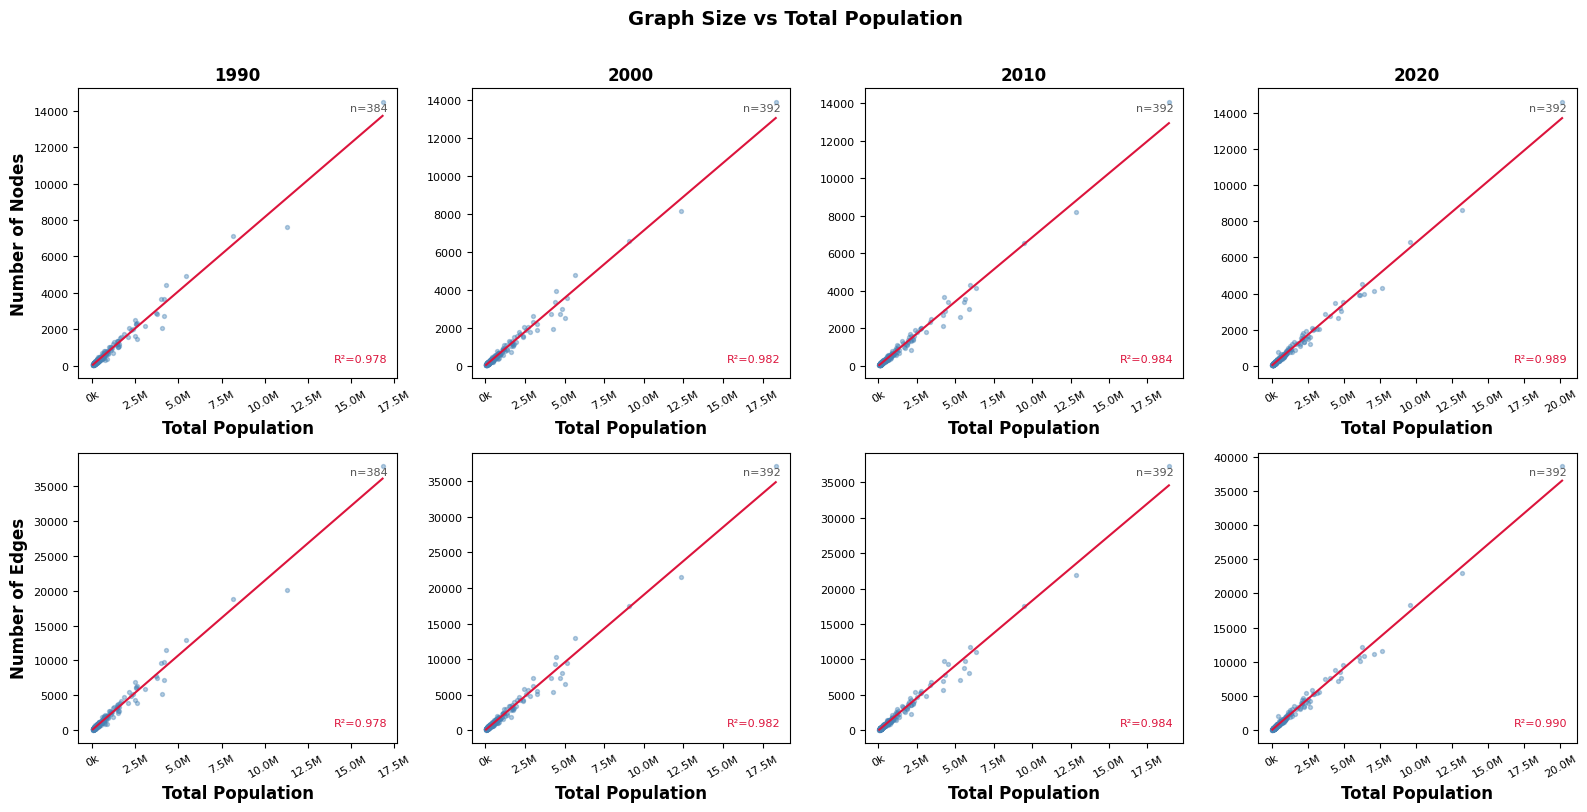

Saved figures/memo_scatter_density_pop.png


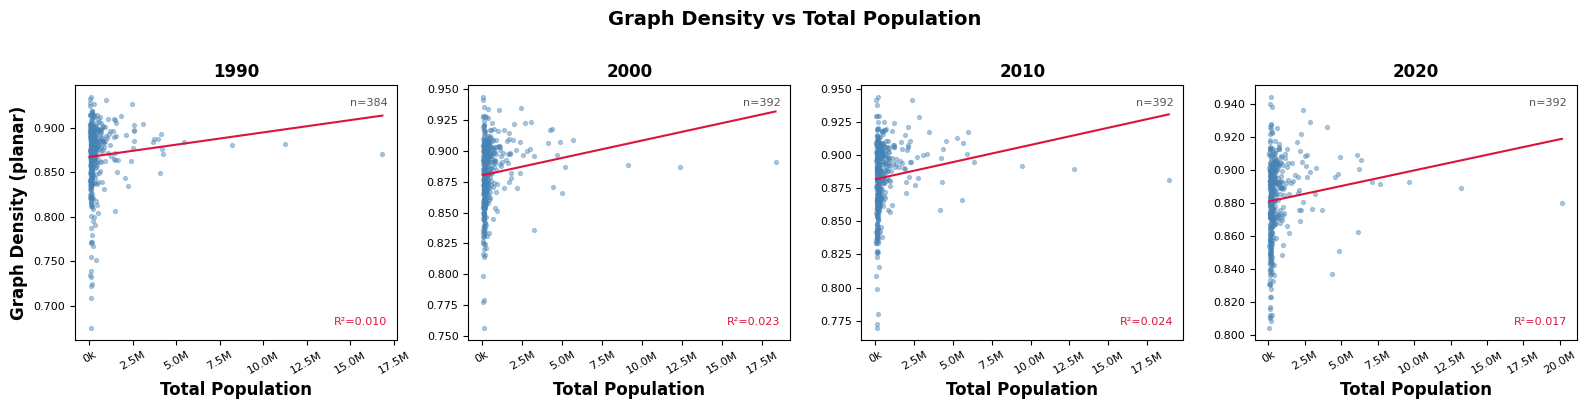

Saved figures/memo_scatter_leaves_degree_pop.png


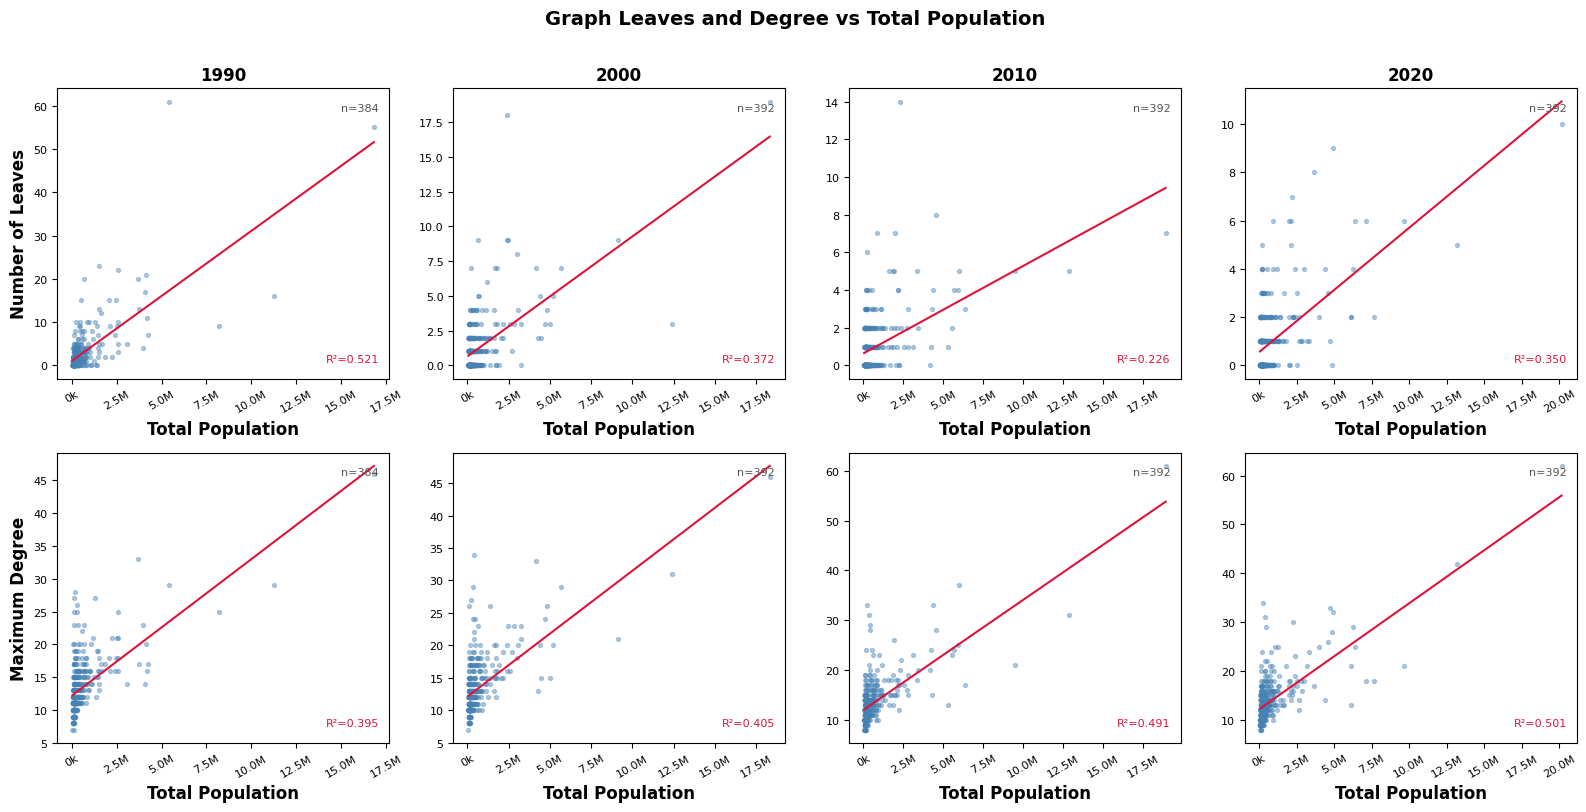

In [96]:
# ── Scatter plots ─────────────────────────────────────────────────────────────

pop_fmt = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'
)
pct_fmt = mticker.FuncFormatter(lambda x, _: f'{x:.0%}')


def scatter_by_year(row_defs, title, filename, log_x=False, log_y=False):
    """
    row_defs: list of (x_key, x_label, y_key, y_label, x_fmt, y_fmt)
    Rows = metric pairs, columns = census years.
    log_x / log_y set the axis to log scale (ticks stay as real values).
    """
    n_rows = len(row_defs)
    n_cols = len(YEARS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                             squeeze=False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for row, (x_key, x_label, y_key, y_label, x_fmt, y_fmt) in enumerate(row_defs):
        for col, yr in enumerate(YEARS):
            ax = axes[row][col]
            pairs = [
                (r[x_key], r[y_key])
                for r in data[yr]
                if r.get(x_key) is not None and r.get(y_key) is not None
                and not (isinstance(r[x_key], float) and np.isnan(r[x_key]))
                and not (isinstance(r[y_key], float) and np.isnan(r[y_key]))
            ]
            if pairs:
                x_vals = np.array([p[0] for p in pairs], dtype=float)
                y_vals = np.array([p[1] for p in pairs], dtype=float)

                ax.scatter(x_vals, y_vals, alpha=0.4, s=8, color='steelblue')

                # best-fit line in log space where applicable
                fx = np.log(x_vals) if log_x else x_vals
                fy = np.log(y_vals) if log_y else y_vals
                m, b = np.polyfit(fx, fy, 1)
                fx_range = np.linspace(fx.min(), fx.max(), 200)
                fy_fit = m * fx_range + b
                ax.plot(
                    np.exp(fx_range) if log_x else fx_range,
                    np.exp(fy_fit)   if log_y else fy_fit,
                    color='crimson', linewidth=1.5, zorder=3,
                )

                r2 = np.corrcoef(fx, fy)[0, 1] ** 2
                ax.text(0.97, 0.05, f'R²={r2:.3f}', transform=ax.transAxes,
                        ha='right', va='bottom', fontsize=8, color='crimson')
                ax.text(0.97, 0.95, f'n={len(x_vals):,}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=8, color='#555')

            if log_x:
                ax.set_xscale('log')
            if log_y:
                ax.set_yscale('log')

            if row == 0:
                ax.set_title(str(yr), fontsize=12, fontweight='bold')
            if col == 0:
                ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
            if x_fmt and not log_x:
                ax.xaxis.set_major_formatter(x_fmt)
                ax.tick_params(axis='x', rotation=30)
            if y_fmt and not log_y:
                ax.yaxis.set_major_formatter(y_fmt)
            ax.tick_params(labelsize=8)

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    fig.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    print(f'Saved figures/{filename}')
    plt.show()


# Plot 1: nodes and edges vs total population
scatter_by_year(
    [
        ('total_pop', 'Total Population', 'n_nodes', 'Number of Nodes', pop_fmt, None),
        ('total_pop', 'Total Population', 'n_edges', 'Number of Edges', pop_fmt, None),
    ],
    'Graph Size vs Total Population',
    'memo_scatter_size_pop.png',
)

# Plot 2: density vs total population (no log scaling)
scatter_by_year(
    [
        ('total_pop', 'Total Population', 'density', 'Graph Density (planar)', pop_fmt,
         mticker.FuncFormatter(lambda x, _: f'{x:.3f}')),
    ],
    'Graph Density vs Total Population',
    'memo_scatter_density_pop.png',
)

# Plot 3: leaves and max degree vs total population
scatter_by_year(
    [
        ('total_pop', 'Total Population', 'n_leaves', 'Number of Leaves', pop_fmt, None),
        ('total_pop', 'Total Population', 'max_deg',  'Maximum Degree',   pop_fmt, None),
    ],
    'Graph Leaves and Degree vs Total Population',
    'memo_scatter_leaves_degree_pop.png',
)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_33588/3344694298.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.015, 1, 0.987], pad=0.1)


Saved figures/memo_graphs_demographics.png


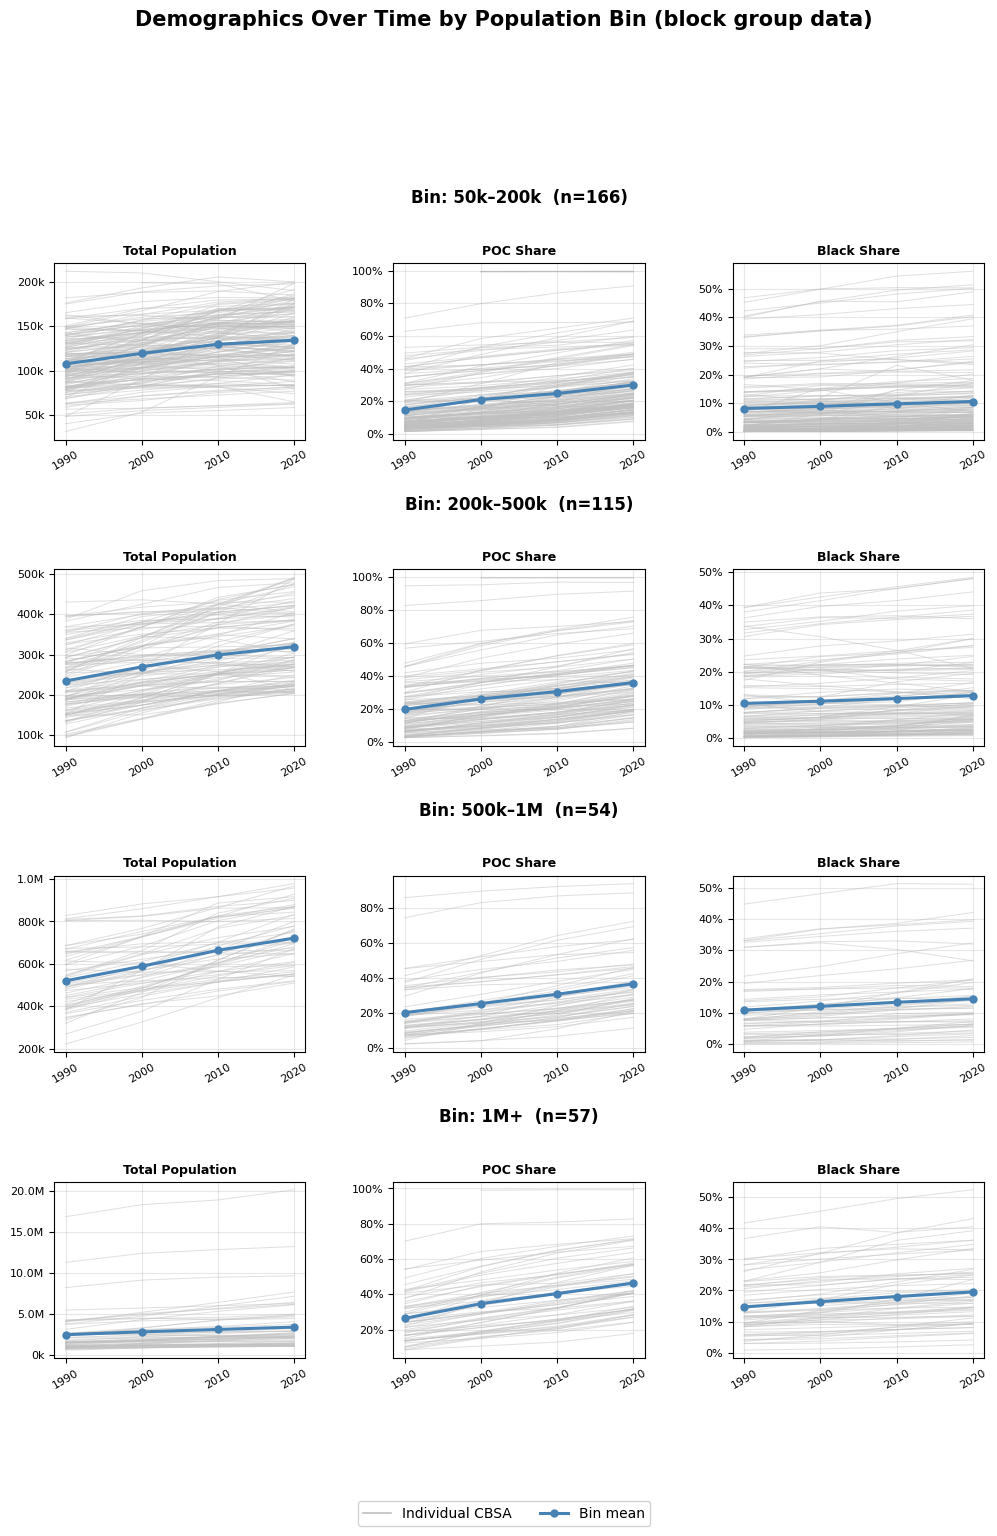

In [97]:
# ── Demographics bin graph ─────────────────────────────────────────────────────

binned_plot(
    [
        ('total_pop',   'Total Population',
         mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')),
        ('poc_share',   'POC Share',
         mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
        ('black_share', 'Black Share',
         mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
    ],
    'memo_graphs_demographics.png',
    'Demographics Over Time',
)

Saved figures/memo_top10_demographics.png


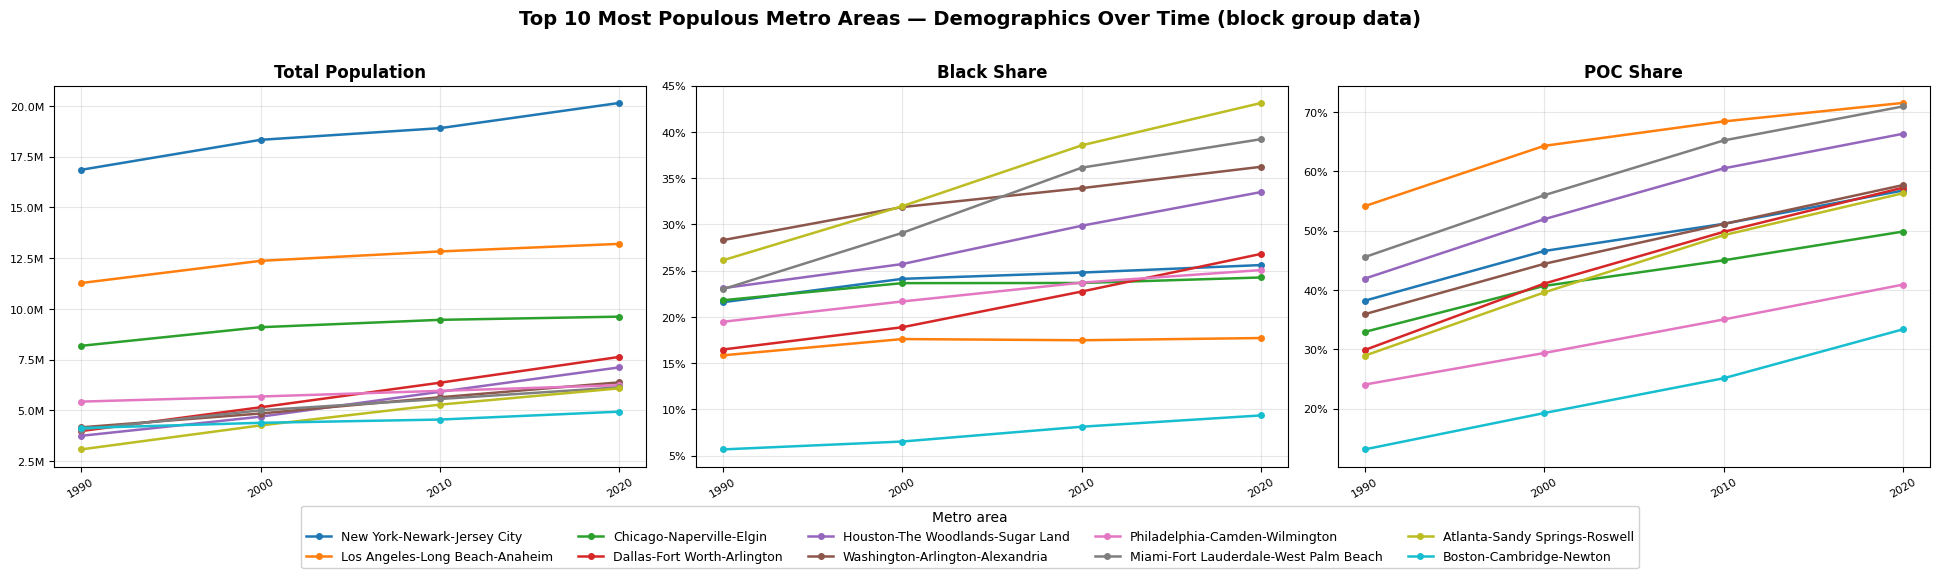

In [98]:
# ── Top-10 demographics spaghetti ─────────────────────────────────────────────

top10_codes_d = sorted(pop_2020, key=lambda c: pop_2020[c], reverse=True)[:10]
top10_names_d = [cbsa_dict.get(c, str(c)).split(',')[0] for c in top10_codes_d]
colors_d      = [cm.tab10(i / 10) for i in range(10)]

DEMO_METRICS = [
    ('total_pop',   'Total Population',
     mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')),
    ('black_share', 'Black Share',
     mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
    ('poc_share',   'POC Share',
     mticker.FuncFormatter(lambda x, _: f'{x:.0%}')),
]

geo_label = 'tract data' if CENSUS_GEOGRAPHY_TYPE == 'tracts' else 'block group data'

fig, axes = plt.subplots(1, len(DEMO_METRICS),
                         figsize=(6.5 * len(DEMO_METRICS), 5))
fig.suptitle(f'Top 10 Most Populous Metro Areas — Demographics Over Time ({geo_label})',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (metric_key, metric_label, fmt) in zip(axes, DEMO_METRICS):
    for i, (code, name) in enumerate(zip(top10_codes_d, top10_names_d)):
        city = cbsa_data.get(code, {})
        pts = [
            (yr, city[yr][metric_key])
            for yr in all_years
            if yr in city
            and city[yr].get(metric_key) is not None
            and not (isinstance(city[yr][metric_key], float)
                     and np.isnan(city[yr][metric_key]))
        ]
        if len(pts) >= 2:
            yrs_i, vals_i = zip(*pts)
            ax.plot(yrs_i, vals_i, color=colors_d[i], linewidth=1.8,
                    marker='o', markersize=4, label=name)

    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    if fmt:
        ax.yaxis.set_major_formatter(fmt)
    ax.set_xticks(all_years)
    ax.tick_params(labelsize=8, axis='x', rotation=30)
    ax.tick_params(labelsize=8, axis='y')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.12), framealpha=0.9,
           title='Metro area', title_fontsize=10)

plt.tight_layout()
fig.savefig('figures/memo_top10_demographics.png', dpi=150, bbox_inches='tight')
print('Saved figures/memo_top10_demographics.png')
plt.show()

Saved figures/memo_leaves_vs_pop_split.png


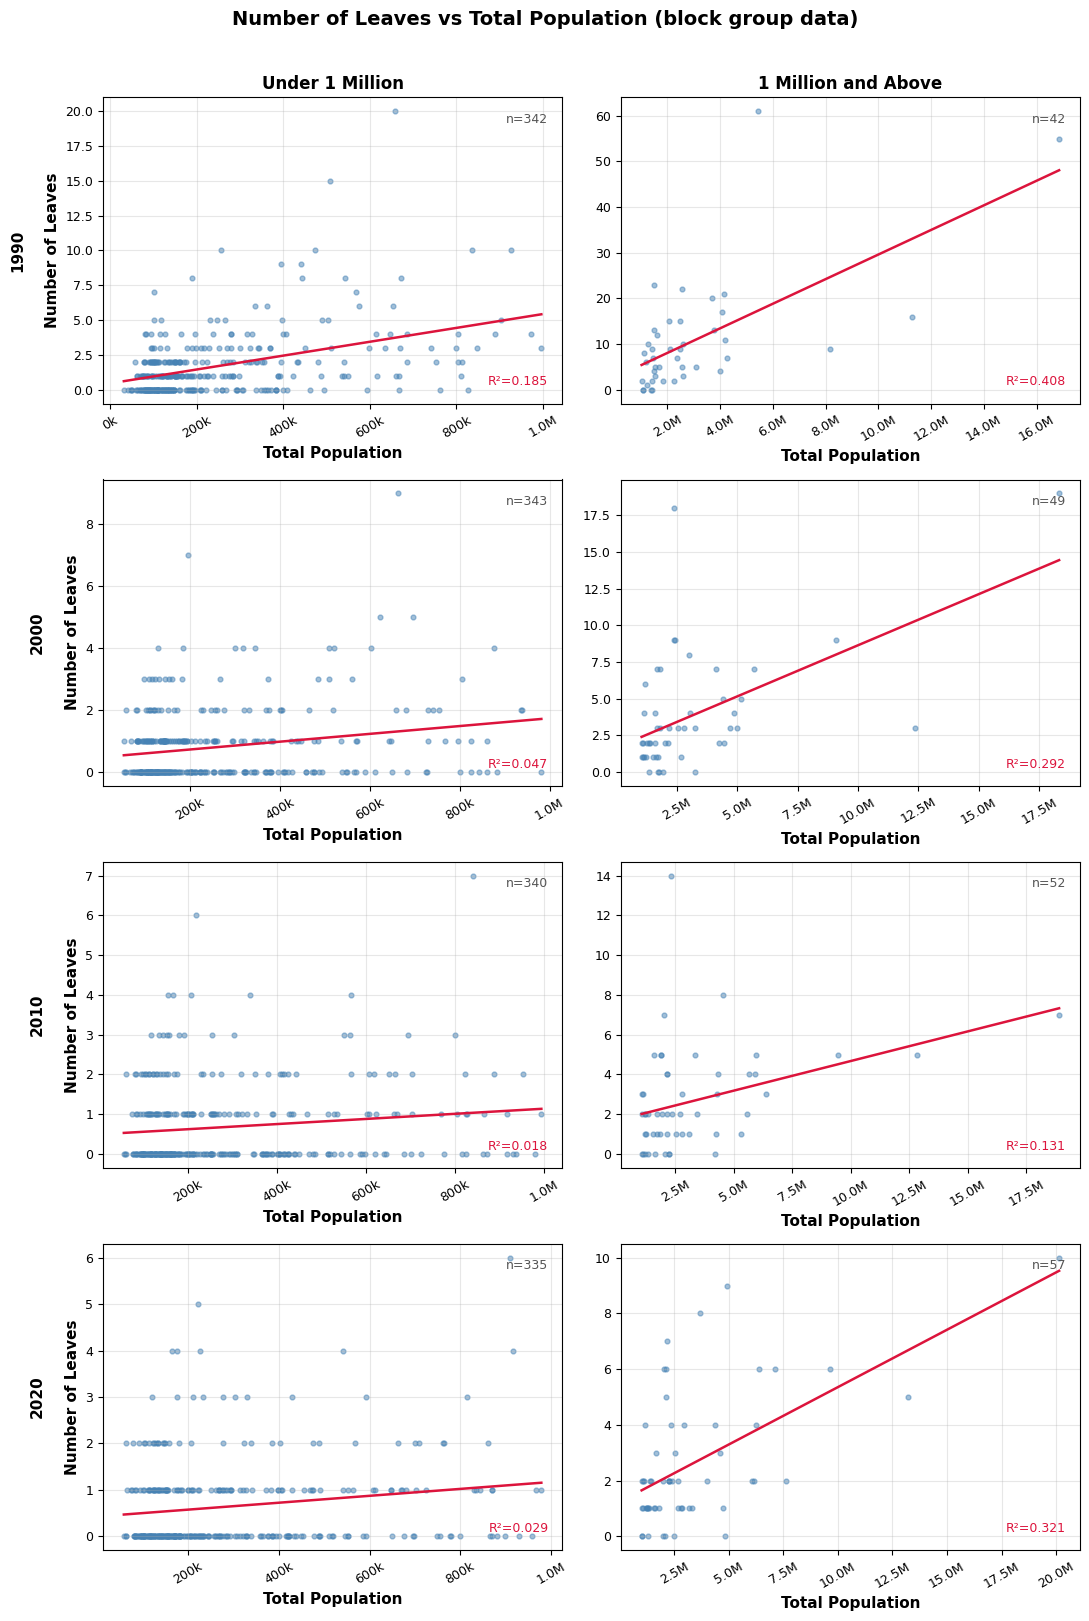

In [99]:
# ── Leaves vs population split by 1M threshold, all decades ──────────────────

pop_fmt_ax = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'
)

fig, axes = plt.subplots(len(YEARS), 2,
                         figsize=(11, 4 * len(YEARS)))
fig.suptitle(f'Number of Leaves vs Total Population ({geo_label})',
             fontsize=14, fontweight='bold', y=1.01)

for row, yr in enumerate(YEARS):
    recs = data[yr]
    splits = [
        ('Under 1 Million',    [r for r in recs if r['total_pop'] <  1_000_000]),
        ('1 Million and Above',[r for r in recs if r['total_pop'] >= 1_000_000]),
    ]

    for col, (panel_title, subset) in enumerate(splits):
        ax = axes[row][col]
        pairs = [(r['total_pop'], r['n_leaves']) for r in subset
                 if r.get('total_pop') is not None and r.get('n_leaves') is not None]

        if pairs:
            x_vals = np.array([p[0] for p in pairs], dtype=float)
            y_vals = np.array([p[1] for p in pairs], dtype=float)

            ax.scatter(x_vals, y_vals, alpha=0.5, s=12, color='steelblue')

            m, b = np.polyfit(x_vals, y_vals, 1)
            x_range = np.linspace(x_vals.min(), x_vals.max(), 200)
            ax.plot(x_range, m * x_range + b, color='crimson',
                    linewidth=1.8, zorder=3)

            r2 = np.corrcoef(x_vals, y_vals)[0, 1] ** 2
            ax.text(0.97, 0.05, f'R²={r2:.3f}', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=9, color='crimson')
            ax.text(0.97, 0.95, f'n={len(x_vals):,}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=9, color='#555')

        if row == 0:
            ax.set_title(panel_title, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{yr}\n\nNumber of Leaves', fontsize=11, fontweight='bold')
        ax.set_xlabel('Total Population', fontsize=11, fontweight='bold')
        ax.xaxis.set_major_formatter(pop_fmt_ax)
        ax.tick_params(labelsize=9, axis='x', rotation=30)
        ax.tick_params(labelsize=9, axis='y')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('figures/memo_leaves_vs_pop_split.png', dpi=150, bbox_inches='tight')
print('Saved figures/memo_leaves_vs_pop_split.png')
plt.show()

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_33588/3344694298.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.015, 1, 0.987], pad=0.1)


Saved figures/memo_graphs_triangle_density.png


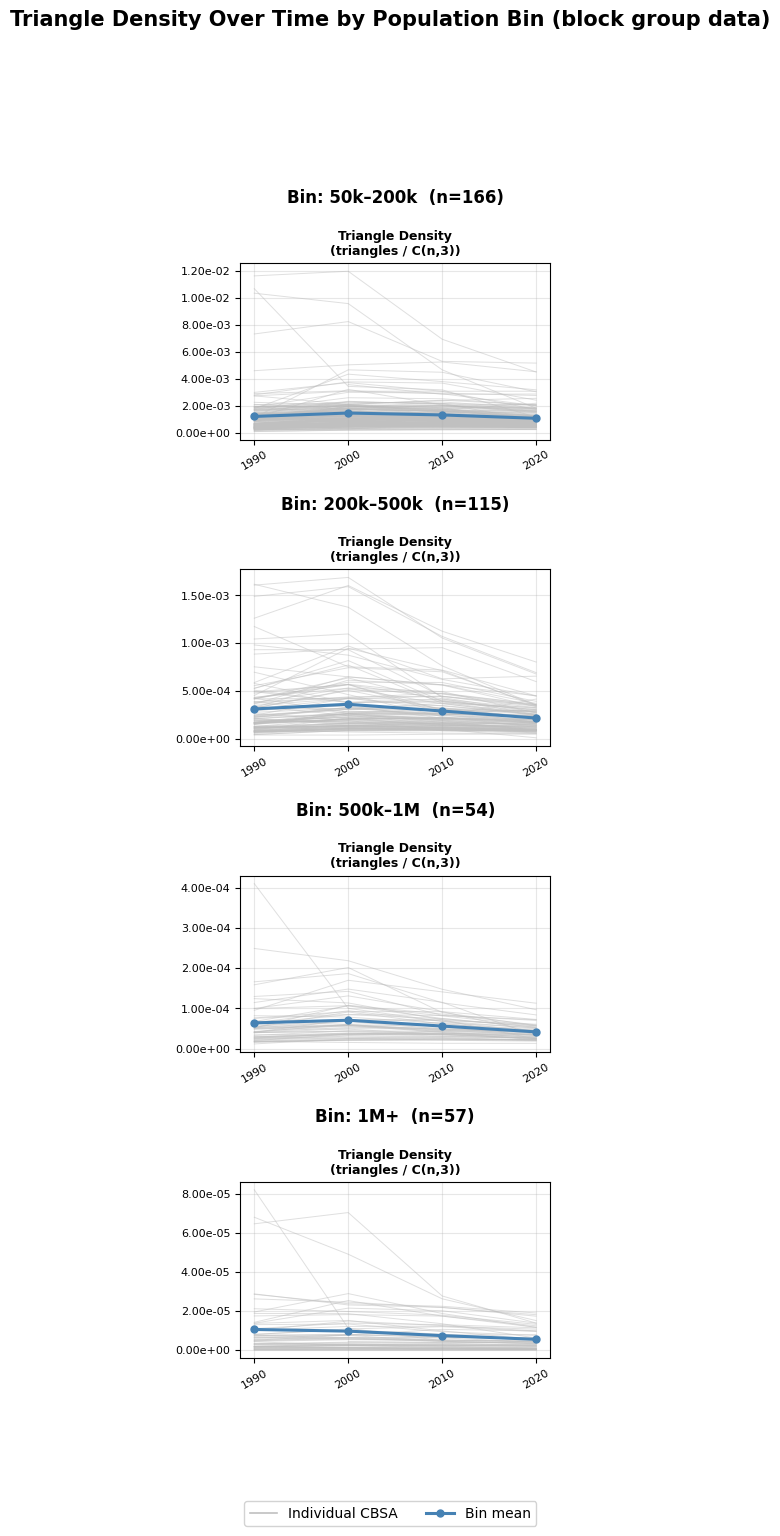

In [100]:
# ── Triangle density bin graph ─────────────────────────────────────────────────
# triangle density = n_triangles / C(n, 3)  where C(n,3) = n*(n-1)*(n-2)/6

binned_plot(
    [('triangle_density', 'Triangle Density\n(triangles / C(n,3))',
      mticker.FuncFormatter(lambda x, _: f'{x:.2e}'))],
    'memo_graphs_triangle_density.png',
    'Triangle Density Over Time',
)

Saved figures/memo_triangle_density_top10.png


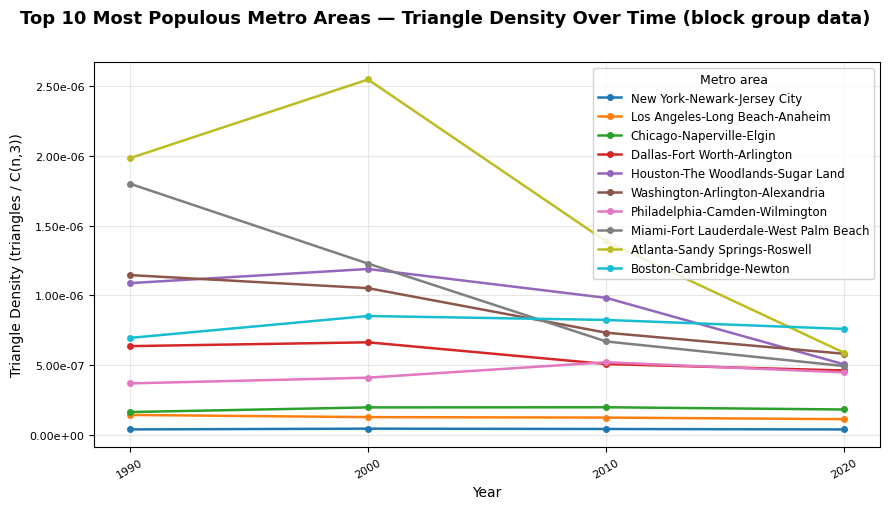

In [101]:
# ── Top-10 triangle density spaghetti ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'Top 10 Most Populous Metro Areas — Triangle Density Over Time ({geo_label})',
    fontsize=13, fontweight='bold', y=1.01,
)

for i, (code, name) in enumerate(zip(top10_codes, top10_names)):
    city = cbsa_data.get(code, {})
    pts = [
        (yr, city[yr]['triangle_density'])
        for yr in all_years
        if yr in city
        and city[yr].get('triangle_density') is not None
        and not (isinstance(city[yr]['triangle_density'], float)
                 and np.isnan(city[yr]['triangle_density']))
    ]
    if len(pts) >= 2:
        yrs_i, vals_i = zip(*pts)
        ax.plot(yrs_i, vals_i, color=colors[i], linewidth=1.8,
                marker='o', markersize=4, label=name)

ax.set_ylabel('Triangle Density (triangles / C(n,3))', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2e}'))
ax.set_xticks(all_years)
ax.tick_params(labelsize=8, axis='x', rotation=30)
ax.tick_params(labelsize=8, axis='y')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8.5, framealpha=0.85, title='Metro area', title_fontsize=9)

plt.tight_layout()
fig.savefig('figures/memo_triangle_density_top10.png', dpi=150, bbox_inches='tight')
print('Saved figures/memo_triangle_density_top10.png')
plt.show()

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_33588/3344694298.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.015, 1, 0.987], pad=0.1)


Saved figures/memo_graphs_std_transitivity.png


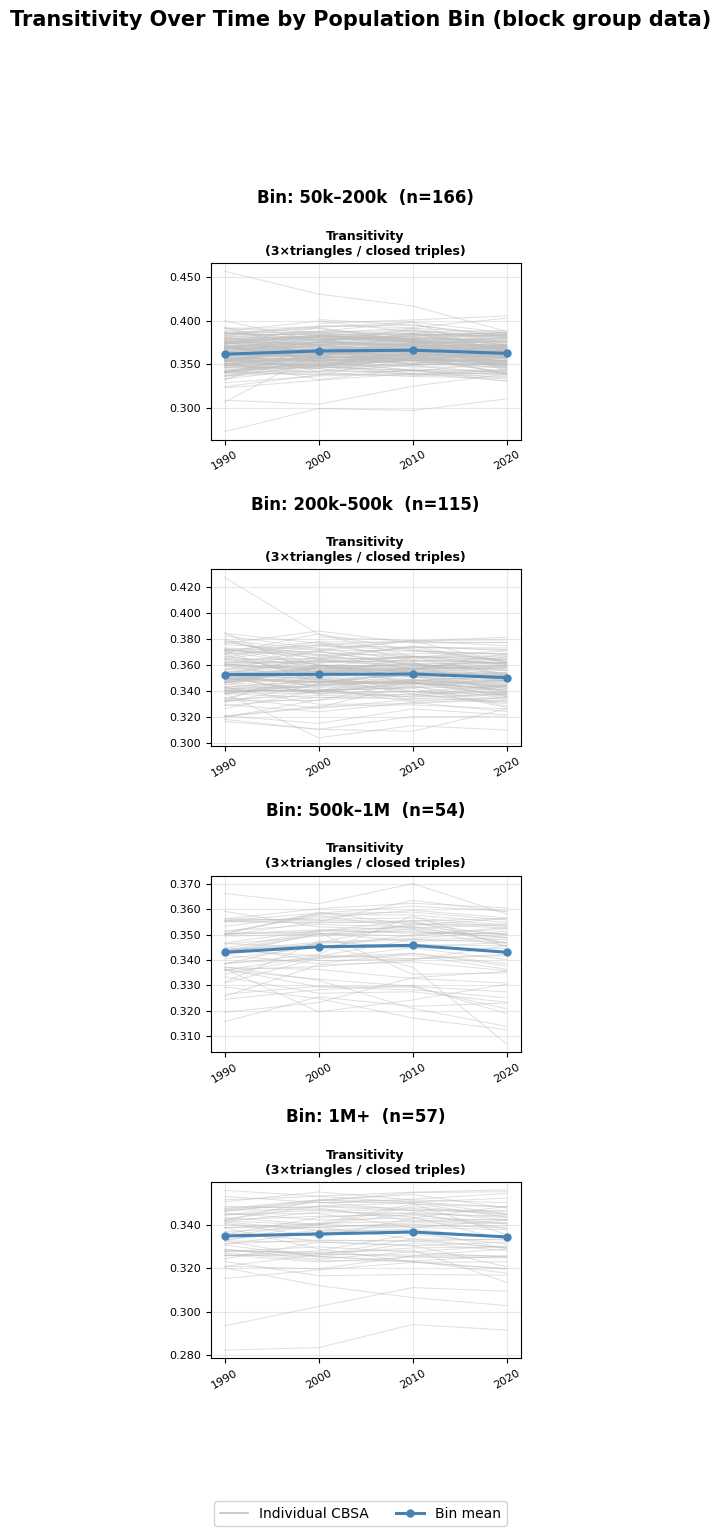

In [102]:
# ── Standard transitivity bin graph ───────────────────────────────────────────
# transitivity = 3 × triangles / closed triples  (closed triples = Σ d*(d-1)/2)

binned_plot(
    [('transitivity', 'Transitivity\n(3×triangles / closed triples)',
      mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))],
    'memo_graphs_std_transitivity.png',
    'Transitivity Over Time',
)

Saved figures/memo_transitivity_top10.png


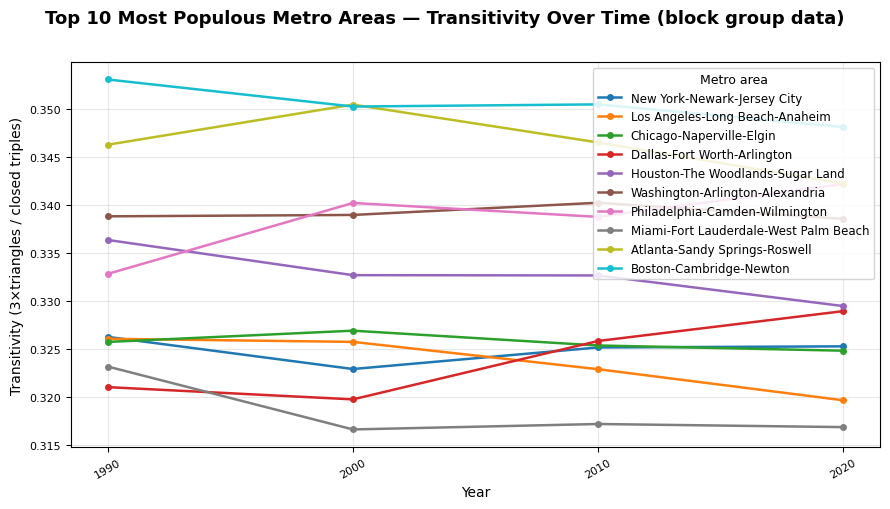

In [103]:
# ── Top-10 standard transitivity spaghetti ────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    f'Top 10 Most Populous Metro Areas — Transitivity Over Time ({geo_label})',
    fontsize=13, fontweight='bold', y=1.01,
)

for i, (code, name) in enumerate(zip(top10_codes, top10_names)):
    city = cbsa_data.get(code, {})
    pts = [
        (yr, city[yr]['transitivity'])
        for yr in all_years
        if yr in city
        and city[yr].get('transitivity') is not None
        and not (isinstance(city[yr]['transitivity'], float)
                 and np.isnan(city[yr]['transitivity']))
    ]
    if len(pts) >= 2:
        yrs_i, vals_i = zip(*pts)
        ax.plot(yrs_i, vals_i, color=colors[i], linewidth=1.8,
                marker='o', markersize=4, label=name)

ax.set_ylabel('Transitivity (3×triangles / closed triples)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.set_xticks(all_years)
ax.tick_params(labelsize=8, axis='x', rotation=30)
ax.tick_params(labelsize=8, axis='y')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8.5, framealpha=0.85, title='Metro area', title_fontsize=9)

plt.tight_layout()
fig.savefig('figures/memo_transitivity_top10.png', dpi=150, bbox_inches='tight')
print('Saved figures/memo_transitivity_top10.png')
plt.show()